Original Equation: y = 4.929972382654457x + -0.563536489624803

Custom Least Squares
Slope: 5.035750222290221
Intercept: -0.12907861188930095

NumPy Least Squares
Slope: 5.035750222290225
Intercept: -0.1290786118893048

Largest Residual:
X = 0.03, Residual = 0.5193

Smallest Residual:
X = 0.52, Residual = 0.0003


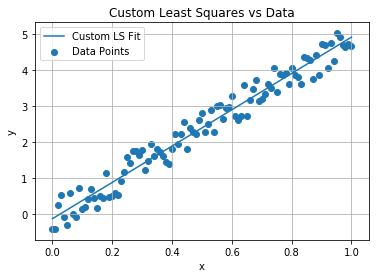

In [9]:
"""
Homework 5 - Code your own Least Squares Method
Revisit the previous Challenge and implement your own Least Squares Method 
Compare your results with the built-in Numpy function
Results should be near the original equation. 
"""

import numpy as np
import matplotlib.pyplot as plt


# my custom LS method
def my_least_squares(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    b = (sum_y - m * sum_x) / n
    return m, b

# my choice of m and b: 
true_m = np.random.uniform(-5, 5)
true_b = np.random.uniform(-2, 2)

# set of data points: X: 0 to 1, steps of .01
X = np.arange(0, 1.01, 0.01)
X = np.sort(X)              # sort X vector 

noise = np.random.uniform(0, 1, len(X)) # random error (between 0 and 1)
Y = true_m * X + true_b + noise         # y = mx + b +/- random_number(0, 1)
print(f"Original Equation: y = {true_m}x + {true_b}")  

m_custom, b_custom = my_least_squares(X, Y)


# numpy LS method
A = np.vstack([X, np.ones(len(X))]).T # matrix
m_numpy, b_numpy = np.linalg.lstsq(A, Y, rcond=None)[0]


# print out the residuals, identify the points with the largest and smallest residual errors
Y_pred = m_custom * X + b_custom
residuals = Y - Y_pred

max_residual_index = np.argmax(np.abs(residuals))
min_residual_index = np.argmin(np.abs(residuals))

print("\nCustom Least Squares")
print(f"Slope: {m_custom}")
print(f"Intercept: {b_custom}")

print("\nNumPy Least Squares")
print(f"Slope: {m_numpy}")
print(f"Intercept: {b_numpy}")

print("\nLargest Residual:")
print(f"X = {X[max_residual_index]:.2f}, Residual = {residuals[max_residual_index]:.4f}")

print("\nSmallest Residual:")
print(f"X = {X[min_residual_index]:.2f}, Residual = {residuals[min_residual_index]:.4f}")


# Compare the results of custom Least Square Method to the the Numpy version
# Plot the points, and the predicted line

x_line = np.linspace(0, 1, 100)
y_line = m_custom * x_line + b_custom

plt.scatter(X, Y, label="Data Points")
plt.plot(x_line, y_line, label="Custom LS Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Custom Least Squares vs Data")
plt.legend()
plt.grid(True)
plt.show()